In [37]:
import pandas as pd

composite_data = pd.read_parquet('../data/composite_data.parquet')

In [38]:
# Examine the data structure
print("Composite data shape:", composite_data.shape)
print("\nColumns:")
print(composite_data.columns.tolist())
print("\nFirst few rows of key columns:")
print(composite_data[['date', 'custom_sentiment', 'finbert_sentiment', 'p+0', 'on_volatile_date', 'adjacent_volatile_date']].head())
print("\nData types:")
print(composite_data.dtypes)

Composite data shape: (39124, 23)

Columns:
['ticker', 'custom_sentiment', 'finbert_sentiment', 'date', 'on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date', 'near_volatile_date', 'p-7', 'p-6', 'p-5', 'p-4', 'p-3', 'p-2', 'p-1', 'p+0', 'p+1', 'p+2', 'p+3', 'p+4', 'p+5', 'p+6', 'p+7']

First few rows of key columns:
         date  custom_sentiment  finbert_sentiment        p+0  \
0  2021-01-28         -1.320963          -1.622274  48.400002   
1  2021-01-28         -0.032856           0.572957  48.400002   
2  2021-01-28         -0.462225           0.609483  48.400002   
3  2021-01-28         -0.462225           0.514058  48.400002   
4  2021-01-28         -0.462225           0.514058  86.300003   

   on_volatile_date  adjacent_volatile_date  
0             False                   False  
1             False                   False  
2             False                   False  
3             False                   False  
4             False                   False

In [39]:
composite_data['r1'] = (composite_data['p+1'] - composite_data['p+0']) / composite_data['p+0']
composite_data['r2'] = (composite_data['p+2'] - composite_data['p+0']) / composite_data['p+0']
composite_data['r3'] = (composite_data['p+3'] - composite_data['p+0']) / composite_data['p+0']
composite_data['r4'] = (composite_data['p+4'] - composite_data['p+0']) / composite_data['p+0']
composite_data['r5'] = (composite_data['p+5'] - composite_data['p+0']) / composite_data['p+0']
composite_data['r6'] = (composite_data['p+6'] - composite_data['p+0']) / composite_data['p+0']
composite_data['r7'] = (composite_data['p+7'] - composite_data['p+0']) / composite_data['p+0']

In [40]:
r1_data = composite_data.dropna(subset=['r1']).sort_values('date').reset_index(drop=True)
r2_data = composite_data.dropna(subset=['r2']).sort_values('date').reset_index(drop=True)
r3_data = composite_data.dropna(subset=['r3']).sort_values('date').reset_index(drop=True)
r4_data = composite_data.dropna(subset=['r4']).sort_values('date').reset_index(drop=True)
r5_data = composite_data.dropna(subset=['r5']).sort_values('date').reset_index(drop=True)
r6_data = composite_data.dropna(subset=['r6']).sort_values('date').reset_index(drop=True)
r7_data = composite_data.dropna(subset=['r7']).sort_values('date').reset_index(drop=True)

In [41]:
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

input_features = ['custom_sentiment', 'finbert_sentiment']

best_rmse = np.inf
best_model = None
best_config = None
perfs = []

for df, target in [(r1_data, 'r1'), (r2_data, 'r2'), (r3_data, 'r3'), (r4_data, 'r4'), (r5_data, 'r5'), (r6_data, 'r6'), (r7_data, 'r7')]:
  for ignore_settings in [[], ['on_volatile_date'], ['on_volatile_date', 'adjacent_volatile_date'], ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date'], ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date', 'near_volatile_date']]:
    for to_ignore in ignore_settings:
      df = df[df[to_ignore] == False].reset_index(drop=True)
    if len(df) < 500:
      continue
    df = df.sort_values('date')
    split_idx = int(len(df) * 0.8)
    train = df.iloc[:split_idx]
    val = df.iloc[split_idx:]
    X_train = train[input_features]
    X_val = val[input_features]
    Y_train = train[target]
    Y_val = val[target]
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, Y_train)
    pred_ridge = ridge.predict(X_val)
    rmse_ridge = root_mean_squared_error(Y_val, pred_ridge)
    perfs.append(("Ridge", ignore_settings, target, rmse_ridge))

    if rmse_ridge < best_rmse:
      best_rmse = rmse_ridge
      best_model = ridge
      best_config = ("Ridge", ignore_settings, target)

    xgb = XGBRegressor(
      n_estimators=200,
      max_depth=3,
      learning_rate=0.05,
      subsample=0.8,
      objective='reg:squarederror',
      tree_method='hist'
    )
    xgb.fit(X_train, Y_train)
    pred_xgb = xgb.predict(X_val)
    rmse_xgb = root_mean_squared_error(Y_val, pred_xgb)
    perfs.append(("XGBoost", ignore_settings, target, rmse_xgb))

    if rmse_xgb < best_rmse:
      best_rmse = rmse_xgb
      best_model = xgb
      best_config = ("XGBoost", ignore_settings, target)

In [42]:
print(perfs)
print(best_rmse)
print(best_config)

[('Ridge', [], 'r1', 0.1243315444296504), ('XGBoost', [], 'r1', 0.12660338720450173), ('Ridge', ['on_volatile_date'], 'r1', 0.12208237770037944), ('XGBoost', ['on_volatile_date'], 'r1', 0.12346616890408744), ('Ridge', ['on_volatile_date', 'adjacent_volatile_date'], 'r1', 0.12301574610558023), ('XGBoost', ['on_volatile_date', 'adjacent_volatile_date'], 'r1', 0.12386065733143817), ('Ridge', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date'], 'r1', 0.12839562206530386), ('XGBoost', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date'], 'r1', 0.12891206914483214), ('Ridge', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date', 'near_volatile_date'], 'r1', 0.1537405518086763), ('XGBoost', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date', 'near_volatile_date'], 'r1', 0.1554012361964043), ('Ridge', [], 'r2', 0.11650344685374811), ('XGBoost', [], 'r2', 0.120212417418157), ('Ridge', ['on_volatile_date'], 'r2'

In [43]:

df = r2_data.copy()
df[df['on_volatile_date'] == False].reset_index(drop=True)
df[df['adjacent_volatile_date'] == False].reset_index(drop=True)

df = df.sort_values('date').reset_index(drop=True)

print(len(df))

split_idx = int(len(df) * 0.8)
test_df = df.iloc[split_idx:]

X_test = test_df[['custom_sentiment', 'finbert_sentiment']]
Y_test = test_df['r2']

39124


In [44]:
y_pred = best_model.predict(X_test)

sign_match = np.sign(y_pred) == np.sign(Y_test)
sign_accuracy = sign_match.mean()

print(f"Sign accuracy for best model: {sign_accuracy:.3f}")

Sign accuracy for best model: 0.498


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle
from scipy import stats

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# Convert performance results to DataFrame for easier analysis
perf_df = pd.DataFrame(perfs, columns=['Model', 'Filters', 'Target', 'RMSE'])
perf_df['Prediction_Days'] = perf_df['Target'].str.extract('(\d+)').astype(int)
perf_df['Filter_Count'] = perf_df['Filters'].apply(len)

print("Performance DataFrame created")
print("Unique targets:", perf_df['Target'].unique())
print("Filter strategies:", perf_df['Filter_Count'].value_counts().sort_index())

Performance DataFrame created
Unique targets: ['r1' 'r2' 'r3' 'r4' 'r5' 'r6' 'r7']
Filter strategies: Filter_Count
0    14
1    14
2    14
3    14
4    14
Name: count, dtype: int64


## 1. Model Performance vs Prediction Horizon Analysis

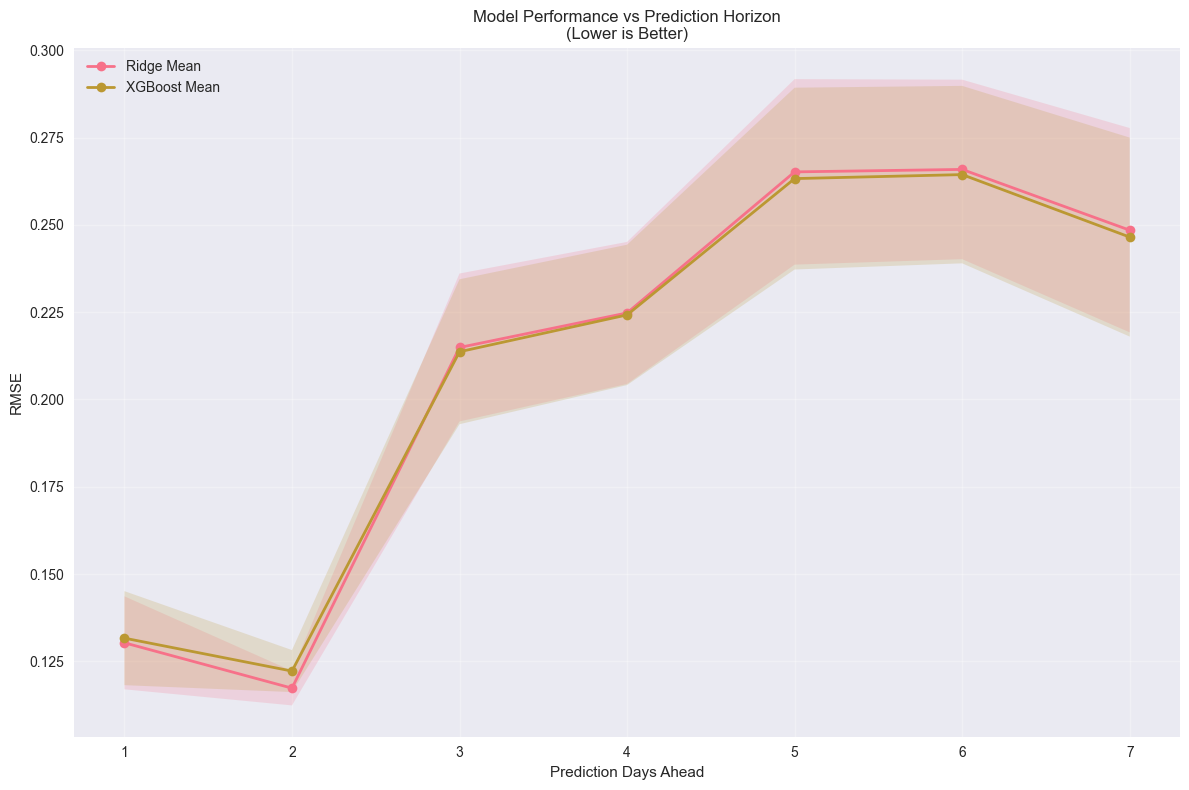

In [46]:
# Plot 1: RMSE by prediction horizon - shows degradation over time
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

for model in ['Ridge', 'XGBoost']:
    model_data = perf_df[perf_df['Model'] == model]
    mean_rmse = model_data.groupby('Prediction_Days')['RMSE'].mean()
    std_rmse = model_data.groupby('Prediction_Days')['RMSE'].std()
    
    ax.plot(mean_rmse.index, mean_rmse.values, marker='o', linewidth=2, label=f'{model} Mean')
    ax.fill_between(mean_rmse.index, 
                    mean_rmse.values - std_rmse.values,
                    mean_rmse.values + std_rmse.values, 
                    alpha=0.2)

ax.set_xlabel('Prediction Days Ahead')
ax.set_ylabel('RMSE')
ax.set_title('Model Performance vs Prediction Horizon\n(Lower is Better)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 📊 How to Read This Plot:
**What it shows**: Model accuracy (RMSE) degrades as prediction horizon increases from 1 to 7 days.

**Key Insights to Look For**:
- **Lower RMSE = Better**: The y-axis shows Root Mean Square Error - lower values mean more accurate predictions
- **Degradation Pattern**: Both models should show increasing RMSE (decreasing accuracy) as days increase
- **Model Comparison**: Compare which model (Ridge vs XGBoost) performs better at different time horizons
- **Uncertainty Bands**: The shaded areas show variability - smaller bands mean more consistent performance

**What This Tells You About Your Trading Strategy**:
- Short-term predictions (1-3 days) are more reliable than long-term (5-7 days)
- If RMSE increases dramatically after day 3, focus on shorter-term strategies
- The model with consistently lower RMSE across all horizons is your best choice

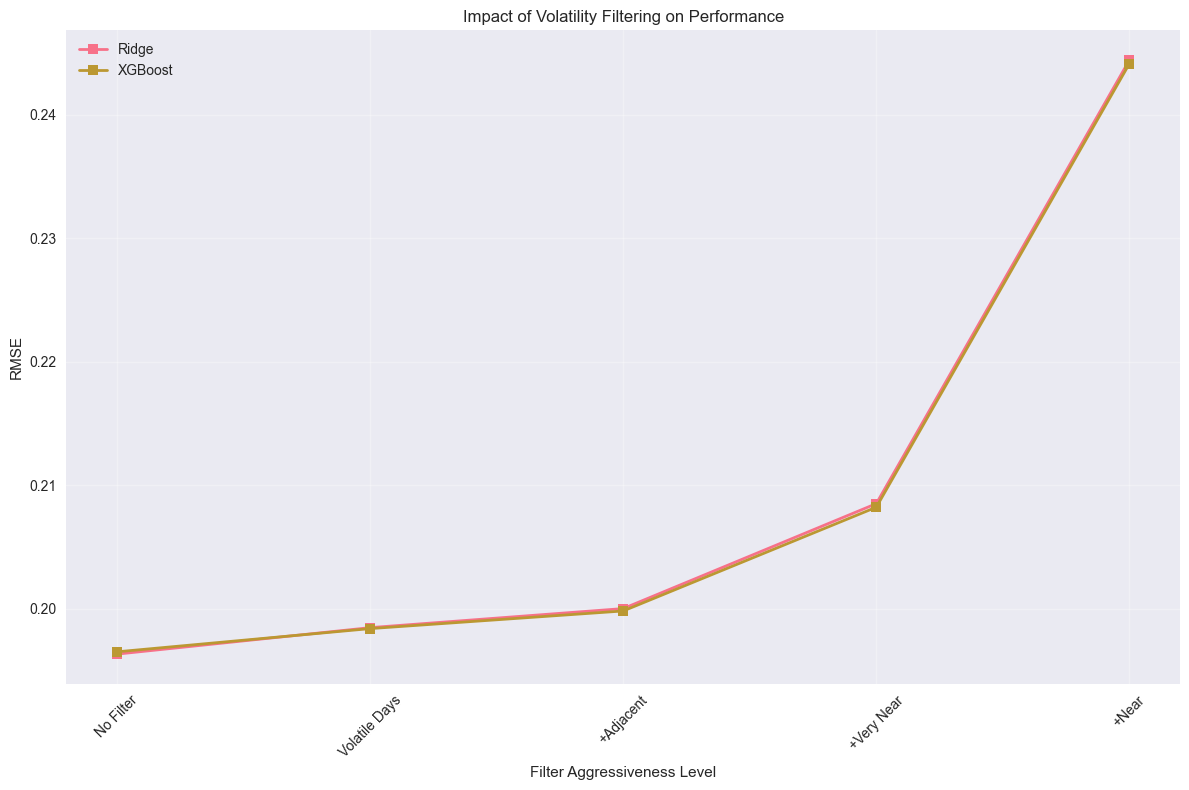

In [47]:
# Plot 2: Impact of volatility filtering
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

filter_labels = {0: 'No Filter', 1: 'Volatile Days', 2: '+Adjacent', 3: '+Very Near', 4: '+Near'}
for model in ['Ridge', 'XGBoost']:
    model_data = perf_df[perf_df['Model'] == model]
    mean_rmse = model_data.groupby('Filter_Count')['RMSE'].mean()
    
    ax.plot(mean_rmse.index, mean_rmse.values, marker='s', linewidth=2, label=model)

ax.set_xlabel('Filter Aggressiveness Level')
ax.set_ylabel('RMSE')
ax.set_title('Impact of Volatility Filtering on Performance')
ax.set_xticks(range(5))
ax.set_xticklabels([filter_labels[i] for i in range(5)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 📊 How to Read This Plot:
**What it shows**: How removing volatile trading days affects prediction accuracy.

**Filter Strategy Levels**:
- **No Filter**: Uses all data points
- **Volatile Days**: Removes days with high volatility
- **+Adjacent**: Also removes days next to volatile days  
- **+Very Near**: Also removes days very close to volatile periods
- **+Near**: Most aggressive filtering - removes all nearby volatile periods

**Key Insights to Look For**:
- **Optimal Filtering**: The lowest point shows the best filter strategy
- **Diminishing Returns**: If RMSE stops improving or gets worse, you're over-filtering
- **Data vs Accuracy Trade-off**: More filtering = less data but potentially better signal

**What This Tells You**:
- If performance improves with filtering, volatility hurts your sentiment signals
- The optimal filter level balances noise reduction with data retention
- If "No Filter" is best, your sentiment analysis works even in volatile markets

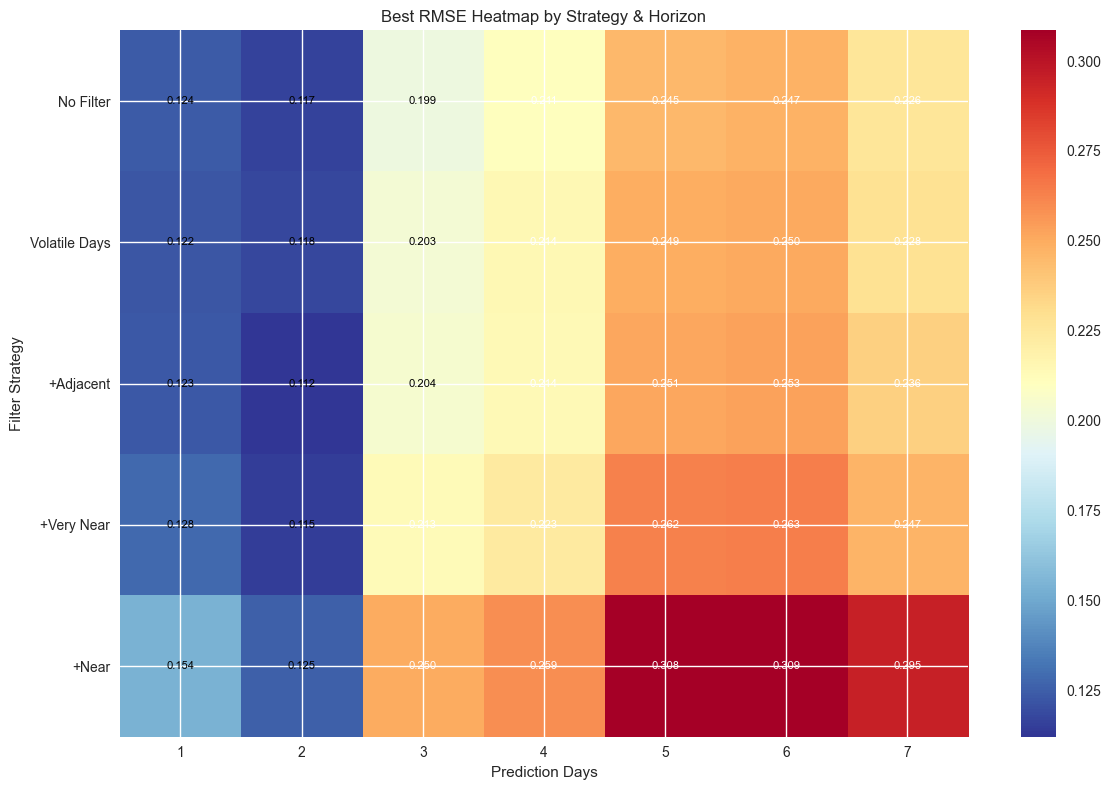

In [48]:
# Plot 3: Best performance by time horizon (heatmap)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

pivot_data = perf_df.pivot_table(values='RMSE', index='Filter_Count', columns='Prediction_Days', aggfunc='min')
im = ax.imshow(pivot_data.values, aspect='auto', cmap='RdYlBu_r')
ax.set_xticks(range(len(pivot_data.columns)))
ax.set_xticklabels(pivot_data.columns)
ax.set_yticks(range(len(pivot_data.index)))
ax.set_yticklabels([filter_labels[i] for i in pivot_data.index])
ax.set_xlabel('Prediction Days')
ax.set_ylabel('Filter Strategy')
ax.set_title('Best RMSE Heatmap by Strategy & Horizon')

# Add text annotations for values
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        ax.text(j, i, f'{pivot_data.iloc[i, j]:.3f}', 
               ha="center", va="center", fontsize=8, color='white' if pivot_data.iloc[i, j] > pivot_data.values.mean() else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 📊 How to Read This Heatmap:
**What it shows**: Best RMSE performance for each combination of filter strategy and prediction horizon.

**Reading the Colors**:
- **Dark Blue**: Excellent performance (low RMSE)
- **Light Blue/White**: Good performance  
- **Yellow/Orange**: Moderate performance
- **Red**: Poor performance (high RMSE)

**Key Insights to Look For**:
- **Sweet Spots**: Dark blue cells show optimal strategy-horizon combinations
- **Patterns**: Do certain filters work better for specific time horizons?
- **Consistency**: Are there strategies that work well across multiple horizons?

**Strategic Implications**:
- **Focus Areas**: Use the darkest blue combinations for your trading strategy
- **Avoid Red Zones**: These combinations are unreliable
- **Time-Specific Strategies**: Different horizons may need different filtering approaches

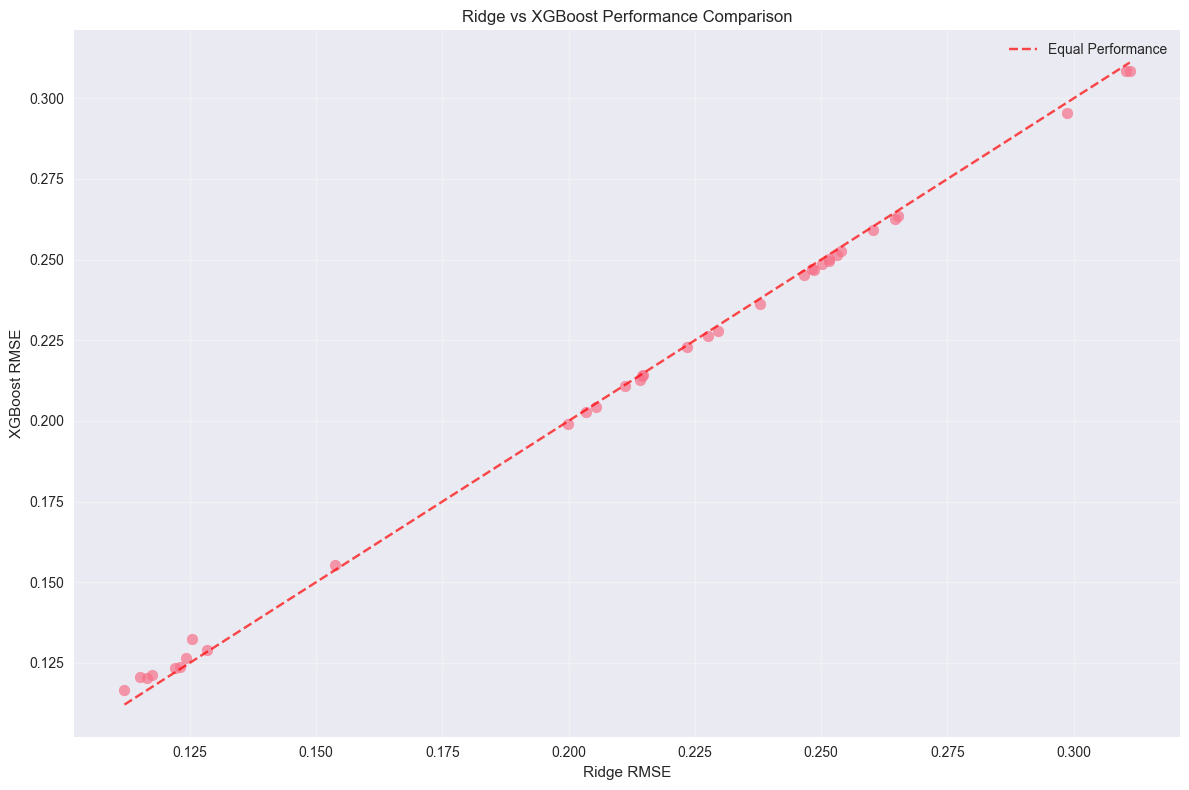

KEY INSIGHTS:
1. Best overall performance: ('Ridge', ['on_volatile_date', 'adjacent_volatile_date'], 'r2')
   RMSE: 0.1121
2. Ridge wins in 10 out of 35 configurations
3. Performance degrades from 1-day to 7-day predictions by 88.9%


In [49]:
# Plot 4: Model comparison scatter plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ridge_data = perf_df[perf_df['Model'] == 'Ridge'][['Target', 'Filter_Count', 'RMSE']].set_index(['Target', 'Filter_Count'])
xgb_data = perf_df[perf_df['Model'] == 'XGBoost'][['Target', 'Filter_Count', 'RMSE']].set_index(['Target', 'Filter_Count'])

ax.scatter(ridge_data['RMSE'], xgb_data['RMSE'], alpha=0.7, s=60)
min_val = min(ridge_data['RMSE'].min(), xgb_data['RMSE'].min())
max_val = max(ridge_data['RMSE'].max(), xgb_data['RMSE'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Equal Performance')
ax.set_xlabel('Ridge RMSE')
ax.set_ylabel('XGBoost RMSE')
ax.set_title('Ridge vs XGBoost Performance Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print key insights
print("KEY INSIGHTS:")
print(f"1. Best overall performance: {best_config}")
print(f"   RMSE: {best_rmse:.4f}")
print(f"2. Ridge wins in {(ridge_data['RMSE'] < xgb_data['RMSE']).sum()} out of {len(ridge_data)} configurations")
print(f"3. Performance degrades from 1-day to 7-day predictions by {((perf_df[perf_df['Prediction_Days']==7]['RMSE'].mean() / perf_df[perf_df['Prediction_Days']==1]['RMSE'].mean() - 1) * 100):.1f}%")

### 📊 How to Read This Scatter Plot:
**What it shows**: Direct comparison of Ridge vs XGBoost performance across all configurations.

**Understanding the Plot**:
- **X-axis**: Ridge model RMSE
- **Y-axis**: XGBoost model RMSE  
- **Red Diagonal Line**: Equal performance line
- **Each Dot**: One configuration (filter + time horizon combination)

**Key Insights**:
- **Below the Line**: XGBoost performs better (lower RMSE)
- **Above the Line**: Ridge performs better
- **Close to Line**: Similar performance
- **Far from Line**: One model clearly dominates

**Decision Making**:
- **Consistent Winner**: If most dots are on one side, that model is generally better
- **Configuration Specific**: Scattered dots mean model choice depends on your specific setup
- **Magnitude Matters**: Distance from the line shows how much better one model is

## 2. Sentiment Analysis Deep Dive

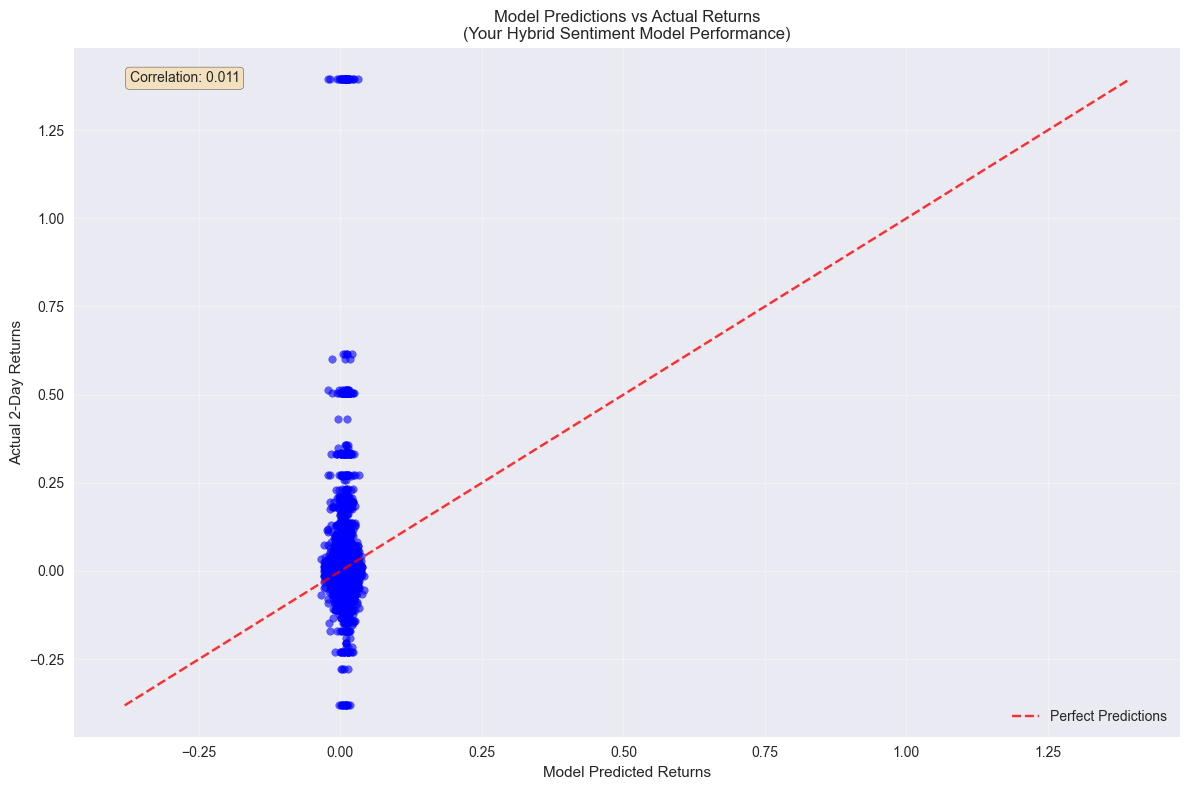

In [51]:
# Plot 1: Model Predictions vs Actual Returns (using test data from your best model)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Use the actual test data and predictions from your model
scatter = ax.scatter(y_pred, Y_test, alpha=0.6, s=30, c='blue')
ax.set_xlabel('Model Predicted Returns')
ax.set_ylabel('Actual 2-Day Returns')
ax.set_title('Model Predictions vs Actual Returns\n(Your Hybrid Sentiment Model Performance)')

# Add perfect prediction line
min_val = min(min(y_pred), min(Y_test))
max_val = max(max(y_pred), max(Y_test))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect Predictions')

# Add correlation info
corr = np.corrcoef(y_pred, Y_test)[0,1]
ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax.transAxes, 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 📊 How to Read This Prediction Quality Plot:
**What it shows**: How well your hybrid sentiment model (custom + FinBERT) predicts actual stock returns.

**Understanding the Elements**:
- **X-axis**: Your model's predicted returns (using both sentiment features)
- **Y-axis**: Actual 2-day stock returns that happened
- **Red Diagonal Line**: Perfect prediction line (where predicted = actual)
- **Correlation Number**: Strength of prediction accuracy (closer to 1.0 = better)

**Quality Indicators**:
- **Points Close to Red Line**: Good predictions
- **Points Far from Red Line**: Poor predictions
- **High Correlation (>0.3)**: Model has predictive power
- **Low Correlation (<0.1)**: Model isn't working well

**Trading Decision Making**:
- **Tight Scatter**: Use larger position sizes (confident predictions)
- **Wide Scatter**: Use smaller positions (uncertain predictions)
- **Systematic Bias**: Points consistently above/below line mean model needs calibration
- **Good Correlation**: Your hybrid sentiment approach is working!

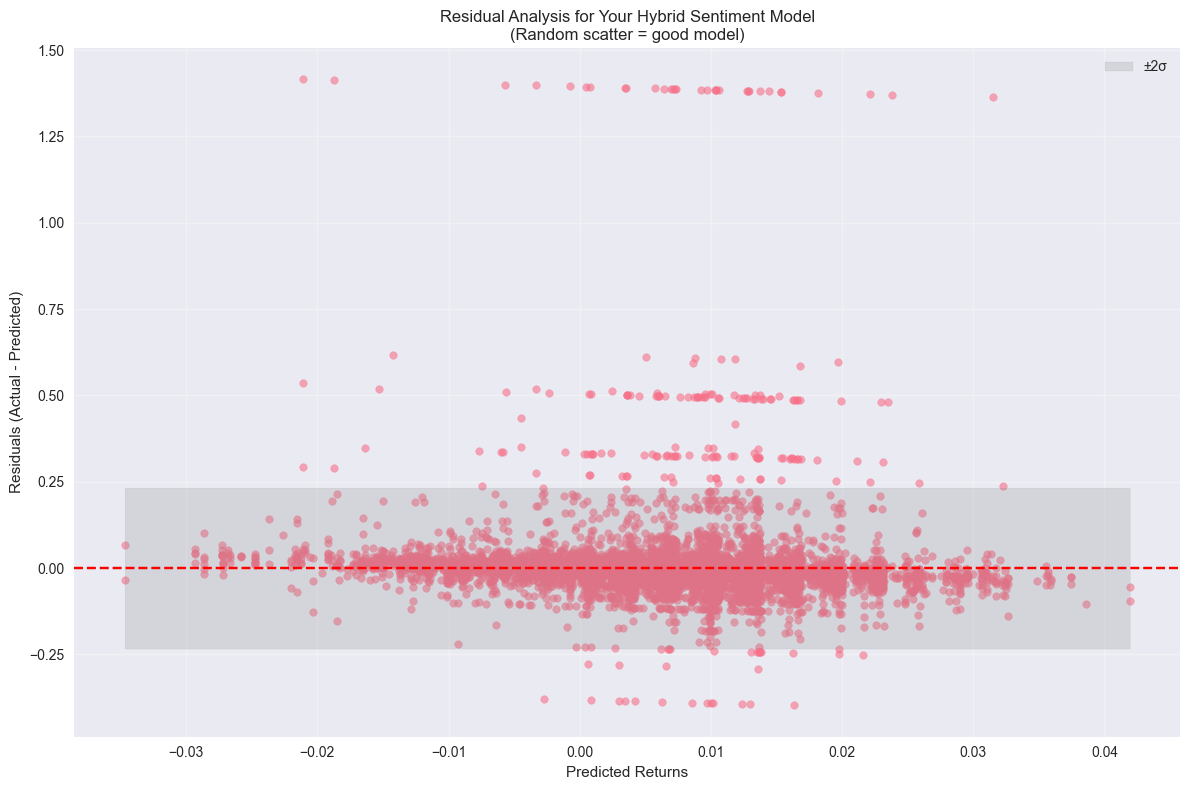

YOUR HYBRID MODEL INSIGHTS:
1. Model Type: Ridge
2. Features Used: Custom Sentiment + FinBERT Sentiment (hybrid)
3. Best Configuration: ('Ridge', ['on_volatile_date', 'adjacent_volatile_date'], 'r2')
4. RMSE: 0.1121
5. Sign Accuracy: 0.498 (% of time model predicts direction correctly)
6. Residual standard deviation: 0.1165
7. Mean absolute residual: 0.0449
8. Heteroscedasticity test p-value: 0.0000 (Heteroscedastic)


In [53]:
# Plot 3: Residual analysis for your hybrid sentiment model
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Use the existing test data and predictions
residuals = Y_test - y_pred
ax.scatter(y_pred, residuals, alpha=0.6, s=30)
ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel('Predicted Returns')
ax.set_ylabel('Residuals (Actual - Predicted)')
ax.set_title('Residual Analysis for Your Hybrid Sentiment Model\n(Random scatter = good model)')

# Add confidence bands
sorted_pred = np.sort(y_pred)
residual_std = np.std(residuals)
ax.fill_between(sorted_pred, -2*residual_std, 2*residual_std, alpha=0.2, color='gray', label='±2σ')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print model performance insights
print("YOUR HYBRID MODEL INSIGHTS:")
print(f"1. Model Type: {type(best_model).__name__}")
print(f"2. Features Used: Custom Sentiment + FinBERT Sentiment (hybrid)")
print(f"3. Best Configuration: {best_config}")
print(f"4. RMSE: {best_rmse:.4f}")
print(f"5. Sign Accuracy: {sign_accuracy:.3f} (% of time model predicts direction correctly)")
print(f"6. Residual standard deviation: {residual_std:.4f}")
print(f"7. Mean absolute residual: {np.mean(np.abs(residuals)):.4f}")

# Check for heteroscedasticity (changing variance)
_, p_value = stats.levene(residuals[y_pred < np.median(y_pred)], 
                         residuals[y_pred >= np.median(y_pred)])

print(f"8. Heteroscedasticity test p-value: {p_value:.4f} ({'Homoscedastic' if p_value > 0.05 else 'Heteroscedastic'})")

### 🔍 Residual Analysis - Model Quality Check:
**What it shows**: How well your model predictions match reality by examining prediction errors.

**Understanding the Elements**:
- **Scatter Plot**: Each point is one prediction vs its error
- **X-axis**: Model's predicted returns
- **Y-axis**: Residuals (actual return - predicted return)
- **Red Dashed Line**: Zero line (perfect predictions)
- **Point Distribution**: Shows prediction quality patterns

**Quality Indicators to Look For**:
- **Random Scatter Around Zero**: Good model (no systematic bias)
- **Funnel Shape**: Model uncertainty increases with prediction magnitude
- **Curved Pattern**: Model missing non-linear relationships
- **Horizontal Bands**: Model has systematic over/under-prediction

**Red Flags**:
- **Clear Trends**: Model consistently wrong in certain ranges
- **Clustering**: Model only works well for specific conditions
- **Wide Spread**: High prediction uncertainty

**Trading Implications**:
- **Tight Around Zero**: High confidence in predictions
- **Wide Spread**: Use larger position sizing margins
- **Systematic Bias**: Adjust predictions by the bias amount
- **Pattern Detection**: May need additional features or different model

**Model Improvement Signals**:
- Add more features if you see clear patterns
- Consider ensemble methods if residuals show structure
- Use different models for different market conditions if clustering appears